In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv


In [2]:
import pandas as pd
import numpy as np
import random as rnd

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier

In [3]:
df=pd.read_csv('/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(df.columns.values)

['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']


<h3>which features are categorical</h3>
.Categorical :Survived,sex,Embarked ,Ordinal:Pclass
<h3>Which features are numerical </h3>
Continous Age Fare,Discrete :SibSp,Parch'



<h3>Which features are mixed data types </h3>
Numerical ,alphanumeric data with in same feature.these are candidates for correcting goal
.Ticket is a mix of numeric and alphanumeric datatypes,Cabin is alphanumeric


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.info()
print('-'*40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
----------------------------------------


In [7]:
df.shape

(891, 12)

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
var=df[['Pclass','Survived']].groupby(['Pclass'],as_index=False).mean().sort_values(by='Survived',ascending=False)


In [10]:
var


,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


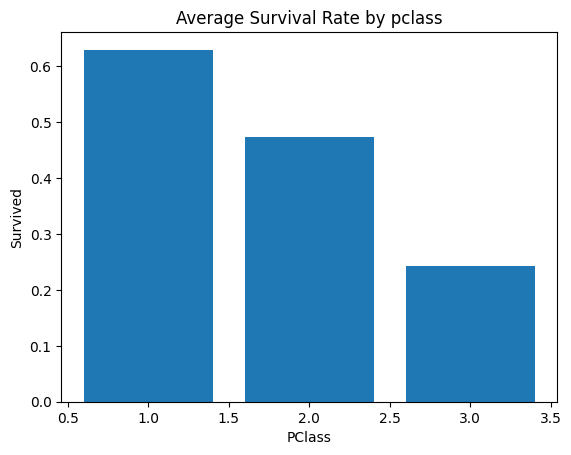

In [11]:
#ploting barchart
plt.bar(var['Pclass'],var['Survived'])
plt.title("Average Survival Rate by pclass")
plt.xlabel('PClass')
plt.ylabel('Survived')
plt.show()

In [12]:
var=df[['Sex','Survived']].groupby(['Sex'],as_index=False).mean().sort_values(by='Survived',ascending=False)


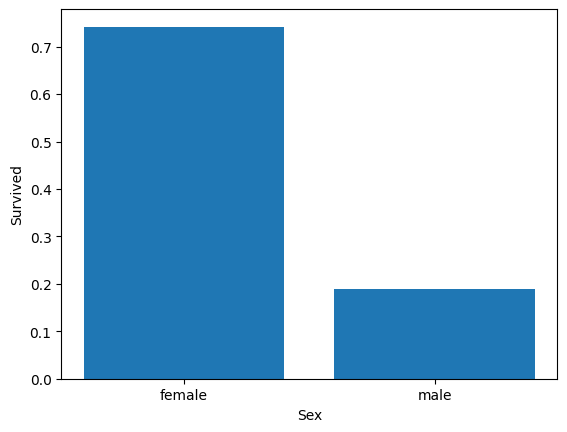

In [13]:
plt.bar(var['Sex'],var['Survived'])
plt.xlabel('Sex')
plt.ylabel('Survived')
plt.show()

In [14]:
var=df[['SibSp','Survived']].groupby(['SibSp'],as_index=False).mean().sort_values('Survived',ascending=False)


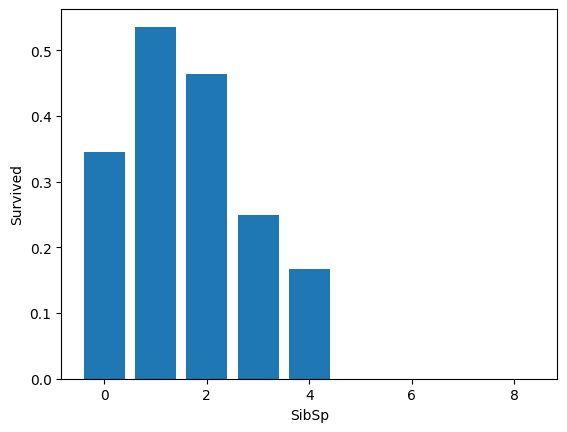

In [15]:
plt.bar(var['SibSp'],var['Survived'])
plt.xlabel('SibSp')
plt.ylabel('Survived')
plt.show()

In [16]:
var=df[['Parch','Survived']].groupby(['Parch'],as_index=False).mean().sort_values(by='Survived',ascending=False)


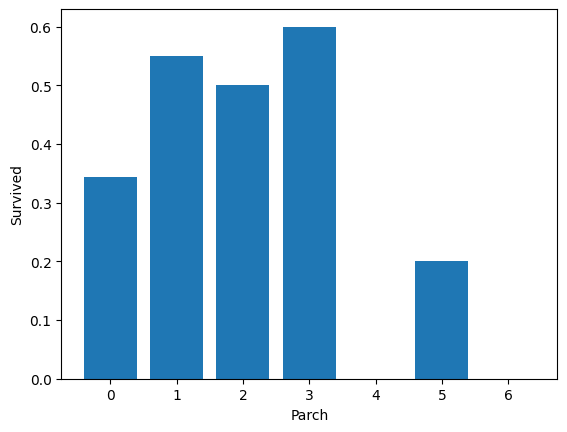

In [17]:
plt.bar(var['Parch'],var['Survived'])
plt.xlabel("Parch")
plt.ylabel("Survived")
plt.show()

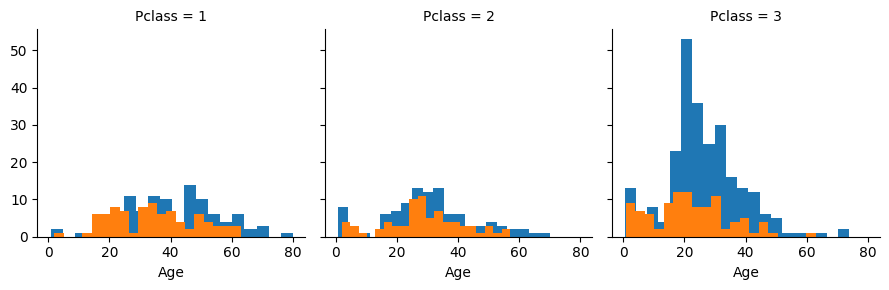

In [18]:
g=sns.FacetGrid(df,col='Pclass',hue='Sex')
g.map(plt.hist,'Age',bins=20)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:723: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


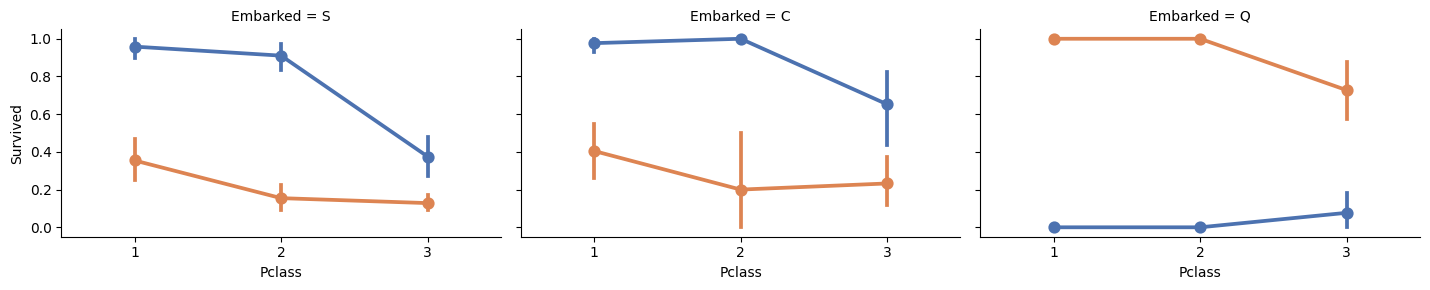

In [19]:
g=sns.FacetGrid(df,col='Embarked',aspect=1.6)
g.map(sns.pointplot,'Pclass','Survived','Sex',palette='deep')

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-pack

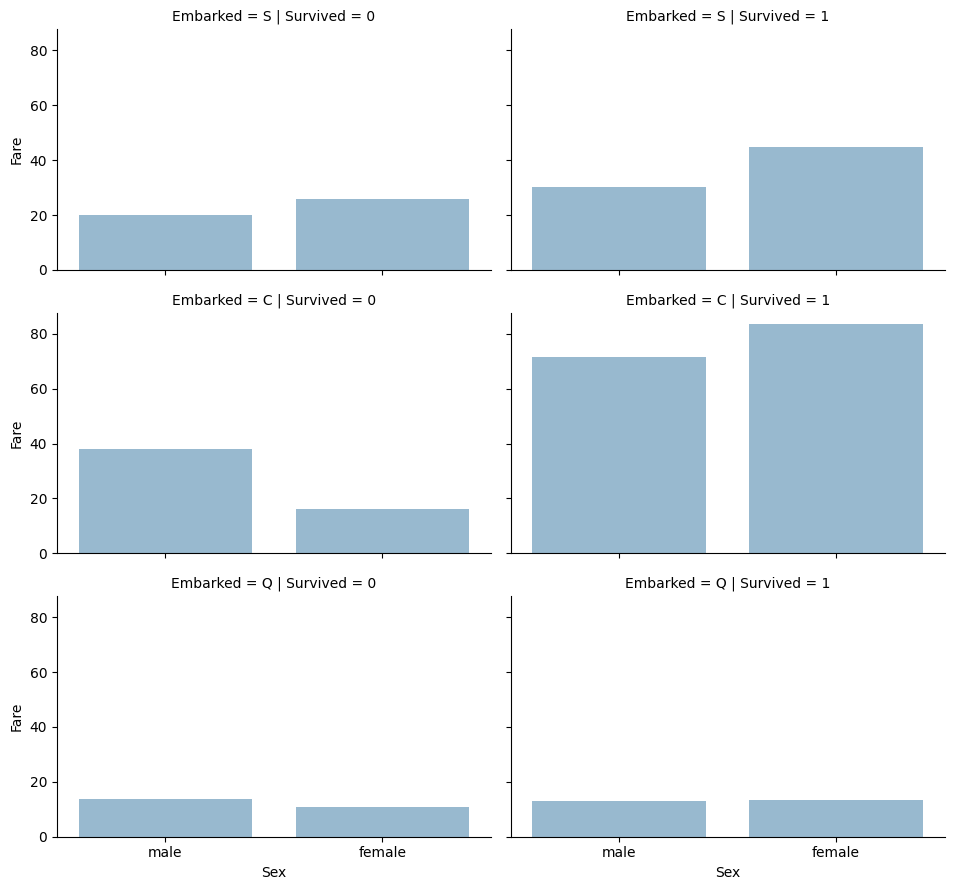

In [20]:
grid = sns.FacetGrid(df, row='Embarked', col='Survived', aspect=1.6)
grid.map(sns.barplot, 'Sex', 'Fare', alpha=.5, ci=None)
grid.add_legend()

In [21]:
df=df.drop(['Ticket','Cabin'],axis=1)


In [22]:
df['Title'] = df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

pd.crosstab(df['Title'], df['Sex'])

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_16/3076444130.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)


Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [23]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr


In [24]:
df['Title']=df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')
df['Title']=df['Title'].replace('Mlle','Miss')
df['Title']=df['Title'].replace('Ms','Miss')
df['Title']=df['Title'].replace('Mme','Mrs')
df[['Title','Survived']].groupby(['Title'],as_index=False).mean()


,Title,Survived
0,Master,0.575000
1,Miss,0.702703
2,Mr,0.156673
3,Mrs,0.793651
4,Rare,0.347826


In [25]:
title_mapping={'Mr':1,'Miss':2,'Mrs':3,'Master':4,'Rare':5}
df['Title']=df['Title'].map(title_mapping)
df['Title']=df['Title'].fillna(0)


In [26]:
df=df.drop(['Name','PassengerId'],axis=1)


In [27]:
df['Sex']=df['Sex'].map({'female':1,'male':0}).astype(int)


In [28]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22.0,1,0,7.2500,S,1
1,1,1,1,38.0,1,0,71.2833,C,3
2,1,3,1,26.0,0,0,7.9250,S,2
3,1,1,1,35.0,1,0,53.1000,S,3
4,0,3,0,35.0,0,0,8.0500,S,1


In [29]:
guess_ages = np.zeros((2,3))
guess_ages

array([[0., 0., 0.],
       [0., 0., 0.]])

In [30]:
for i in range(0, 2):
    for j in range(0, 3):

        guess_df = df[
            (df['Sex'] == i) &
            (df['Pclass'] == j + 1)
        ]['Age'].dropna()

        age_guess = guess_df.median()
        print(age_guess)

        guess_ages[i, j] = int(age_guess / 0.5 + 0.5) * 0.5


for i in range(0, 2):
    for j in range(0, 3):

        df.loc[
            (df['Age'].isnull()) &
            (df['Sex'] == i) &
            (df['Pclass'] == j + 1),
            'Age'
        ] = guess_ages[i, j]


df['Age'] = df['Age'].astype(int)

        

40.0
30.0
25.0
35.0
28.0
21.5


In [31]:
df['Age'].isnull().sum()

np.int64(0)

In [32]:
df['AgeBand']=pd.cut(df['Age'],5)
df['AgeBand']

0      (16.0, 32.0]
1      (32.0, 48.0]
2      (16.0, 32.0]
3      (32.0, 48.0]
4      (32.0, 48.0]
           ...     
886    (16.0, 32.0]
887    (16.0, 32.0]
888    (16.0, 32.0]
889    (16.0, 32.0]
890    (16.0, 32.0]
Name: AgeBand, Length: 891, dtype: category
Categories (5, interval[float64, right]): [(-0.08, 16.0] < (16.0, 32.0] < (32.0, 48.0] < (48.0, 64.0] < (64.0, 80.0]]

In [33]:
new_df=df[['AgeBand','Survived']].groupby(['AgeBand'],as_index=False)
new_df=new_df.mean().sort_values(by='AgeBand',ascending=False)


/tmp/ipykernel_16/862031619.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_df=df[['AgeBand','Survived']].groupby(['AgeBand'],as_index=False)


In [34]:
new_df.head()

,AgeBand,Survived
4,"(64.0, 80.0]",0.090909
3,"(48.0, 64.0]",0.434783
2,"(32.0, 48.0]",0.412037
1,"(16.0, 32.0]",0.337374
0,"(-0.08, 16.0]",0.550000


In [35]:
 df.loc[ df['Age'] <= 16, 'Age'] = 0
 df.loc[(df['Age'] > 16) & (df['Age'] <= 32), 'Age'] = 1
 df.loc[(df['Age'] > 32) & (df['Age'] <= 48), 'Age'] = 2
 df.loc[(df['Age'] > 48) & (df['Age'] <= 64), 'Age'] = 3
 df.loc[ df['Age'] > 64, 'Age']
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,AgeBand
0,0,3,0,1,1,0,7.2500,S,1,"(16.0, 32.0]"
1,1,1,1,2,1,0,71.2833,C,3,"(32.0, 48.0]"
2,1,3,1,1,0,0,7.9250,S,2,"(16.0, 32.0]"
3,1,1,1,2,1,0,53.1000,S,3,"(32.0, 48.0]"
4,0,3,0,2,0,0,8.0500,S,1,"(32.0, 48.0]"


In [36]:
df['FamilySize']=df['SibSp']+df['Parch']+1
df['IsAlone']=0
df.loc[df['FamilySize']==1,'IsAlone']=1

In [37]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,AgeBand,FamilySize,IsAlone
0,0,3,0,1,1,0,7.2500,S,1,"(16.0, 32.0]",2,0
1,1,1,1,2,1,0,71.2833,C,3,"(32.0, 48.0]",2,0
2,1,3,1,1,0,0,7.9250,S,2,"(16.0, 32.0]",1,1
3,1,1,1,2,1,0,53.1000,S,3,"(32.0, 48.0]",2,0
4,0,3,0,2,0,0,8.0500,S,1,"(32.0, 48.0]",1,1


In [38]:
df=df.drop(['Parch','SibSp','FamilySize'],axis=1)


In [39]:
df['Age*Class']=df.Age*df.Pclass
df.loc[:,['Age*Class','Age','Pclass']].head(10)

,Age*Class,Age,Pclass
0,3,1,3
1,2,2,1
2,3,1,3
3,2,2,1
4,6,2,3
5,3,1,3
6,3,3,1
7,0,0,3
8,3,1,3
9,0,0,2


In [40]:
freq_port = df.Embarked.dropna().mode()[0]
freq_port

'S'

In [41]:
df['Embarked']=df['Embarked'].fillna(freq_port)
df[['Embarked','Survived']].groupby(['Embarked'],as_index=False).mean().sort_values(by='Survived',ascending=False)


,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


In [42]:
df['Embarked']=df['Embarked'].map({'S':0,'C':1,'Q':2}).astype(int)


In [43]:
df['Fare'].fillna(df['Fare'].dropna().median(), inplace=True)

/tmp/ipykernel_16/180599093.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fare'].fillna(df['Fare'].dropna().median(), inplace=True)


In [44]:
df['FareBand']=pd.qcut(df['Fare'],4)
df[['FareBand','Survived']].groupby(['FareBand'],as_index=False).mean().sort_values(by='FareBand',ascending=False)


/tmp/ipykernel_16/3999630853.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[['FareBand','Survived']].groupby(['FareBand'],as_index=False).mean().sort_values(by='FareBand',ascending=False)


,FareBand,Survived
3,"(31.0, 512.329]",0.581081
2,"(14.454, 31.0]",0.454955
1,"(7.91, 14.454]",0.303571
0,"(-0.001, 7.91]",0.197309


#### df.head()

In [45]:
df.loc[df['Fare']<=7.91,'Fare']=0
df.loc[(df['Fare']>7.91)&(df['Fare']<=14.45),'Fare']=1
df.loc[(df['Fare']>14.45)&(df['Fare']<=31.0),'Fare']=2
df.loc[(df['Fare']>31.0),'Fare']=3
df=df.drop('FareBand',axis=1)
df=df.drop('AgeBand',axis=1)
df['Fare']=df['Fare'].astype(int)

In [46]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [48]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)


In [49]:
#Logistic Regression
logreg=LogisticRegression()
logreg.fit(x_train,y_train)
y_pred=logreg.predict(x_test)
acc_log=accuracy_score(y_pred,y_test)
acc_log

0.8156424581005587

In [50]:
#Support Vector Machines
svc=SVC()
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
acc_svc=accuracy_score(y_pred,y_test)
acc_svc

0.7988826815642458

In [51]:
knn=KNeighborsClassifier(n_neighbors=4)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
acc_kn=accuracy_score(y_pred,y_test)
acc_kn


0.8324022346368715

In [52]:
gaussian=GaussianNB()
gaussian.fit(x_train,y_train)
y_pred=gaussian.predict(x_test)
acc_guass=accuracy_score(y_pred,y_test)
acc_guass

0.6927374301675978

In [53]:
perceptron=Perceptron()
perceptron.fit(x_train,y_train)
y_pred=perceptron.predict(x_test)
acc_per=accuracy_score(y_pred,y_test)
acc_per

0.6871508379888268

In [54]:
# Linear SVC

linear_svc = LinearSVC()
linear_svc.fit(x_train, y_train)
Y_pred = linear_svc.predict(x_test)
acc_linear_svc = accuracy_score(y_pred,y_test)
acc_linear_svc

0.6871508379888268

In [55]:

sgd = SGDClassifier()
sgd.fit(x_train, y_train)
Y_pred = sgd.predict(x_test)
acc_sgd = accuracy_score(y_pred,y_test)
acc_sgd

0.6871508379888268

In [56]:
# Decision Tree

decision_tree = DecisionTreeClassifier()
decision_tree.fit(x_train, y_train)
Y_pred = decision_tree.predict(x_test)
acc_decision_tree = accuracy_score(y_pred,y_test)
acc_decision_tree

0.6871508379888268

In [57]:
random_forest=RandomForestClassifier(n_estimators=100)
random_forest.fit(x_train,y_train)
y_pred=random_forest.predict(x_test)
acc_ran=accuracy_score(y_test,y_pred)
acc_ran

0.8379888268156425

In [58]:
model=pd.DataFrame({

    'Models':['Support Vector Machines', 'KNN', 'Logistic Regression', 
              'Random Forest', 'Naive Bayes', 'Perceptron', 
              'Stochastic Gradient Decent', 'Linear SVC', 
              'Decision Tree'],
    'Score':[acc_svc, acc_kn, acc_log, 
              acc_ran, acc_guass, acc_per, 
              acc_sgd, acc_linear_svc, acc_decision_tree]}
)
model.sort_values(by='Score',ascending=False)

,Models,Score
3,Random Forest,0.837989
1,KNN,0.832402
2,Logistic Regression,0.815642
0,Support Vector Machines,0.798883
4,Naive Bayes,0.692737
5,Perceptron,0.687151
6,Stochastic Gradient Decent,0.687151
7,Linear SVC,0.687151
8,Decision Tree,0.687151


In [59]:
clf1=LogisticRegression()
clf2=RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [60]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble  import VotingClassifier 


In [61]:
# In the next I am going to do ensembles techniques and boosting techniques and do some hyperparameter tuning 

estimators=[('lr',clf1),('rf',clf2),('knn',clf3)]
vc=VotingClassifier(estimators=estimators,voting='hard')

x=cross_val_score(vc,x_train,y_train,scoring='accuracy')

print(np.round(np.mean(x),2))


0.79


In [62]:
#using soft voting 

estimators=[('lr',clf1),('rf',clf2),('knn',clf3)]
vc=VotingClassifier(estimators=estimators,voting='soft')

x=cross_val_score(vc,x_train,y_train,scoring='accuracy')

print(np.round(np.mean(x),2))


0.81


In [63]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,0,3,0,1,0,0,1,0,3
1,1,1,1,2,3,1,3,0,2
2,1,3,1,1,1,0,2,1,3
3,1,1,1,2,3,0,3,0,2
4,0,3,0,2,1,0,1,1,6


<h1>Weighted Voting</h1>

In [64]:
X = df.drop(columns=['Survived'])
y = df['Survived']

# 2. Run the weight optimization loop
for i in range(1, 4):
    for j in range(1, 4):
        for k in range(1, 4):
            # Fixed naming syntax (VotingClassifier)
            vc = VotingClassifier(estimators=estimators, voting='soft', weights=[i, j, k])
            
            # Passed the full, matching datasets to cross_val_score
            scores = cross_val_score(vc, X, y, cv=10, scoring='accuracy')
            
            print("for i={}, j={}, k={}".format(i, j, k), np.round(np.mean(scores), 2))

for i=1, j=1, k=1 0.8
for i=1, j=1, k=2 0.8
for i=1, j=1, k=3 0.81
for i=1, j=2, k=1 0.81
for i=1, j=2, k=2 0.8
for i=1, j=2, k=3 0.8
for i=1, j=3, k=1 0.81
for i=1, j=3, k=2 0.81
for i=1, j=3, k=3 0.8
for i=2, j=1, k=1 0.8
for i=2, j=1, k=2 0.79
for i=2, j=1, k=3 0.8
for i=2, j=2, k=1 0.8
for i=2, j=2, k=2 0.8
for i=2, j=2, k=3 0.8
for i=2, j=3, k=1 0.8
for i=2, j=3, k=2 0.8
for i=2, j=3, k=3 0.8
for i=3, j=1, k=1 0.8
for i=3, j=1, k=2 0.8
for i=3, j=1, k=3 0.8
for i=3, j=2, k=1 0.8
for i=3, j=2, k=2 0.8
for i=3, j=2, k=3 0.8
for i=3, j=3, k=1 0.8
for i=3, j=3, k=2 0.8
for i=3, j=3, k=3 0.8


In [65]:
from sklearn.ensemble import AdaBoostClassifier
abc=AdaBoostClassifier()
np.mean(cross_val_score(abc,X,y,scoring='accuracy',cv=10))

np.float64(0.7868039950062422)

In [66]:
#do hyperparameter tunning using grid search cv
from sklearn.model_selection import GridSearchCV
grid=dict()
grid['n_estimators']=[10,50,100,500]
grid['learning_rate']=[0.0001,0.000001,0.001,0.01,0.1,1.0]
grid['algorithm']=['SAMME','SAMME.R']

gridsearch=GridSearchCV(estimator=AdaBoostClassifier(),param_grid=grid,n_jobs=-1,cv=10,scoring='accuracy')
gridresult=gridsearch.fit(X,y)
print("Best:%f using %s" % (gridresult.best_score_,gridresult.best_params_))


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

Best:0.800225 using {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 500}
